# Fitness Advantage Analysis

Analyze the fitness advantage of a group of genotypes (peak supernode) over
external neighbors across drug concentrations.

1. **Explore graph** — load and visualize to identify the target group
2. **Compute fitness advantage** — 1-mut and 2-mut external neighbors
3. **Visualize** — box plot for publication

## 1. Explore Graph & Identify Target Group

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Nature journal style
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "lines.linewidth": 1.0,
    "lines.markersize": 4,
    "figure.dpi": 150,
    "savefig.dpi": 1000,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
sns.set_style("ticks")

# Nature column widths
SINGLE_COL = 89 / 25.4   # 89mm in inches
DOUBLE_COL = 183 / 25.4   # 183mm in inches

In [ ]:
import math
from fitness_landscape_graph.graph_analyzer import GraphAnalyzer, VisConfig
concentration = 12.0
graph_path = f"../exp-01-reproduce-results/outputs/run1-reproduce-results/azt_{int(concentration)}_0.graphml"
# here the graph_path should be the output path of generate_graph.sh
ga = GraphAnalyzer(graph_path)

# Visualize — node IDs are shown in the plot
config = VisConfig()
config.x_mode = "average"
config.figure_width = 1600
config.figure_height = 1100
config.edge_width_scaling = lambda w: max(0.5, min(3.0, math.log1p(w) * 0.3))

fig = ga.plot(config=config)
fig.show()

In [3]:
# From the plot, identify the node of interest and extract its genotypes
# Example: use the peak node (highest fitness peak)
group_genotypes = ga.get_peak_genotypes(rank=0)
print(f"Group size: {len(group_genotypes)}")
print(f"Sample genotypes: {list(group_genotypes)[:5]}")

Group size: 1917
Sample genotypes: ['PK.KN...K.M.D', 'PK.....SK.ML.', 'P..KH.....M.D', '..VKHT..K.M.D', 'PKVKN........']


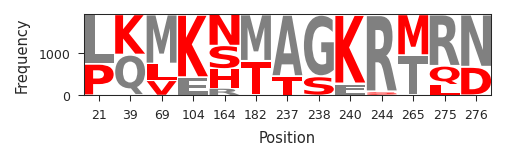

In [4]:
import os
from fitness_landscape_graph.make_logo import plot_logo, all_mutations, intended

output_dir = f"./outputs/fitness-advantage-azt-{int(concentration)}"
os.makedirs(output_dir, exist_ok=True)

# Sequence logo of the group genotypes
fig_logo = plot_logo(
    list(group_genotypes),
    all_mutations,
    intended,
    figsize=(SINGLE_COL, SINGLE_COL * 0.2),
)
fig_logo.savefig(f"{output_dir}/group_logo_azt_{int(concentration)}.png", bbox_inches="tight", dpi=1000)
fig_logo.savefig(f"{output_dir}/group_logo_azt_{int(concentration)}.pdf", bbox_inches="tight")
plt.show()

## 2. Compute Fitness Advantage

In [5]:
import polars as pl
from fitness_landscape_graph.preprocess import preprocess_data
from fitness_landscape_graph.fitness_advantage import FitnessAdvantageAnalyzer

# Load data
project_root = "../.."
processed_data = preprocess_data(
    amp_path=f"{project_root}/data/raw/combined-auc/genotype_auc_sorted_ampicillin.csv",
    azt_path=f"{project_root}/data/raw/combined-auc/genotype_auc_sorted_aztreonam.csv",
    amp_pairs_path=f"{project_root}/data/processed/amp_pairs.csv",
    azt_pairs_path=f"{project_root}/data/processed/azt_pairs.csv",
    clean_nulls_flag=True,
)

azt_long_df = processed_data["azt"]["long"]
azt_pairs_df = processed_data["azt"]["pairs"]

print(f"Long table: {len(azt_long_df)} rows")
print(f"Pairs table: {len(azt_pairs_df)} rows")
print(f"Concentrations: {sorted(azt_long_df['concentration'].unique().to_list())}")

Long table: 442352 rows
Pairs table: 3980880 rows
Concentrations: [0.0, 0.44, 1.33, 4.0, 12.0, 36.0, 108.0, 324.0]


In [6]:
# Compute fitness advantage
analyzer = FitnessAdvantageAnalyzer(azt_pairs_df, azt_long_df)
result_df = analyzer.compute_fitness_advantage(
    group_genotypes=group_genotypes,
    max_distance=2,
)

print(f"Total comparisons: {result_df.height}")
result_df.head(10)

Total comparisons: 1690488


group_member,neighbor,distance,group_member_fitness,neighbor_fitness,fitness_diff,concentration
str,str,i32,f64,f64,f64,f64
"""P..KNTT.K.M.D""","""P.VKNTT.K.M.D""",1,3.180066,3.046433,0.133633,0.0
"""....S...K..Q.""","""....S...K..QD""",1,3.225326,3.187093,0.038233,0.0
"""PK.KS..SK...D""","""PK.KS..SK..QD""",1,3.17548,3.095302,0.080179,0.0
""".K.K...SK.MQD""",""".K.K...SKCMQD""",1,3.421236,3.269526,0.151711,0.0
"""PK.KH..SK..Q.""","""PK.KH..SKC.Q.""",1,3.050987,3.302598,-0.251611,0.0
""".K.KH.....M.D""",""".K.KH....CM.D""",1,3.052346,3.250657,-0.198311,0.0
"""..LKNT.......""","""..LKNT...C...""",1,3.206773,3.192563,0.014209,0.0
"""...KS...K.MQD""","""...K....K.MQD""",1,3.290272,3.267841,0.022432,0.0
"""..VKH...K.M.D""","""..VKH.....M.D""",1,3.247064,3.113186,0.133878,0.0


In [7]:
# Summary statistics
import numpy as np

for conc in sorted(result_df["concentration"].unique().to_list()):
    conc_data = result_df.filter(pl.col("concentration") == conc)
    for dist in sorted(conc_data["distance"].unique().to_list()):
        dist_data = conc_data.filter(pl.col("distance") == dist)
        diffs = dist_data["fitness_diff"].to_list()
        if diffs:
            print(
                f"  conc={conc:>6.1f}  dist={dist}  "
                f"n={len(diffs):>5d}  "
                f"median={np.median(diffs):>+.3f}  "
                f"mean={np.mean(diffs):>+.3f}"
            )

  conc=   0.0  dist=1  n=17030  median=+0.006  mean=+0.006
  conc=   0.0  dist=2  n=194281  median=+0.005  mean=+0.006
  conc=   0.4  dist=1  n=17030  median=+0.096  mean=+0.232
  conc=   0.4  dist=2  n=194281  median=+0.214  mean=+0.391
  conc=   1.3  dist=1  n=17030  median=+0.285  mean=+0.501
  conc=   1.3  dist=2  n=194281  median=+0.799  mean=+0.706
  conc=   4.0  dist=1  n=17030  median=+1.093  mean=+0.969
  conc=   4.0  dist=2  n=194281  median=+1.351  mean=+1.162
  conc=  12.0  dist=1  n=17030  median=+1.489  mean=+1.444
  conc=  12.0  dist=2  n=194281  median=+1.612  mean=+1.548
  conc=  36.0  dist=1  n=17030  median=+0.768  mean=+0.908
  conc=  36.0  dist=2  n=194281  median=+0.944  mean=+1.045
  conc= 108.0  dist=1  n=17030  median=+0.074  mean=+0.264
  conc= 108.0  dist=2  n=194281  median=+0.094  mean=+0.363
  conc= 324.0  dist=1  n=17030  median=+0.014  mean=+0.053
  conc= 324.0  dist=2  n=194281  median=+0.025  mean=+0.085


## 3. Visualization

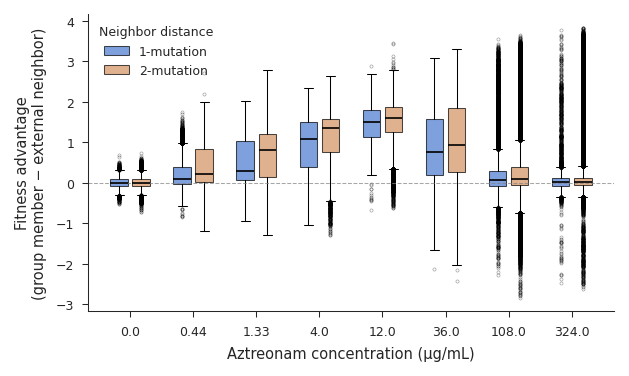

In [8]:
import numpy as np

concentrations = sorted(result_df["concentration"].unique().to_list())
distances = sorted(result_df["distance"].unique().to_list())

fig, ax = plt.subplots(figsize=(SINGLE_COL*1.2, SINGLE_COL*1.2 * 0.6))

n_conc = len(concentrations)
n_dist = len(distances)
width = 0.35
x_base = np.arange(n_conc)

palette = {1: "#4878CF", 2: "#D4915E"}
dist_labels = {1: "1-mutation", 2: "2-mutation"}

for i, dist in enumerate(distances):
    dist_df = result_df.filter(pl.col("distance") == dist)
    box_data = []
    positions = []
    for j, conc in enumerate(concentrations):
        conc_data = dist_df.filter(pl.col("concentration") == conc)["fitness_diff"].to_list()
        if conc_data:
            box_data.append(conc_data)
            positions.append(x_base[j] + (i - (n_dist - 1) / 2) * width)

    if not box_data:
        continue

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True,
        showfliers=True,
        flierprops={"markersize": 1.5, "alpha": 0.4, "markeredgewidth": 0.3},
        medianprops={"color": "black", "linewidth": 0.8},
        whiskerprops={"linewidth": 0.5},
        capprops={"linewidth": 0.5},
        boxprops={"edgecolor": "black", "linewidth": 0.5},
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(palette.get(dist, "grey"))
        patch.set_alpha(0.7)
    bp["boxes"][0].set_label(dist_labels[dist])

ax.axhline(y=0, color="grey", linestyle="--", linewidth=0.5, alpha=0.7)

ax.set_xticks(x_base)
ax.set_xticklabels([str(c) for c in concentrations])
ax.set_xlabel("Aztreonam concentration (\u00b5g/mL)")
ax.set_ylabel("Fitness advantage\n(group member \u2212 external neighbor)")

# Clean legend
legend = ax.legend(title="Neighbor distance", frameon=False, loc="upper left")
legend.get_title().set_fontsize(6)

sns.despine(ax=ax)
plt.tight_layout()

plt.show()

In [9]:
# Save figure and data
fig.savefig(f"{output_dir}/fitness_advantage_boxplot_azt_{int(concentration)}.pdf", bbox_inches="tight")
fig.savefig(f"{output_dir}/fitness_advantage_boxplot_azt_{int(concentration)}.png", bbox_inches="tight")
result_df.write_csv(f"{output_dir}/fitness_advantage_data_azt_{int(concentration)}.csv")

print(f"Saved to {output_dir}")

Saved to ./outputs/fitness-advantage-azt-12
